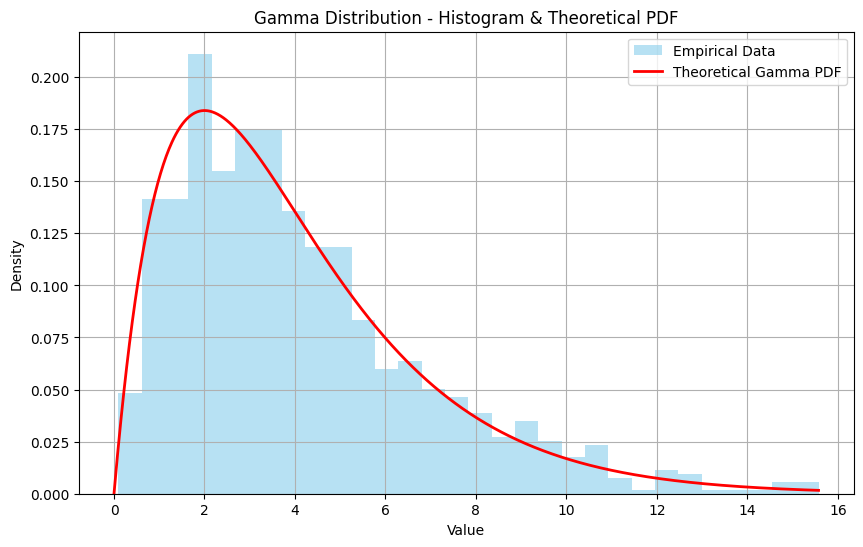

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

np.random.seed(42)

# Gamma分布参数
shape = 2.0
scale = 2.0

# 从Gamma分布生成样本数据
sample_size = 1000
data = np.random.gamma(shape, scale, sample_size)

# 绘制伽玛分布的直方图
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', label='Empirical Data')

# 计算理论概率密度
x = np.linspace(0, np.max(data), 1000)
pdf = gamma.pdf(x, a=shape, scale=scale)

# 在直方图上绘制理论概率密度曲线
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Gamma PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Gamma Distribution - Histogram & Theoretical PDF')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import TweedieRegressor

np.random.seed(42)

# 生成模拟数据: X 为自变量，y 为因变量，y 服从伽玛分布
n_samples = 1000
X = np.random.uniform(0, 10, n_samples).reshape(-1, 1)
# 这里构建 y 的真实模型： y = a*X^2 + b + 噪声，其中噪声服从Gamma分布
a, b = 0.5, 2.0
# 生成带有伽玛噪声的目标值
noise = np.random.gamma(shape=2.0, scale=2.0, size=n_samples)
y = a * X.flatten()**2 + b + noise

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mean Squared Error: 7.977608085110571


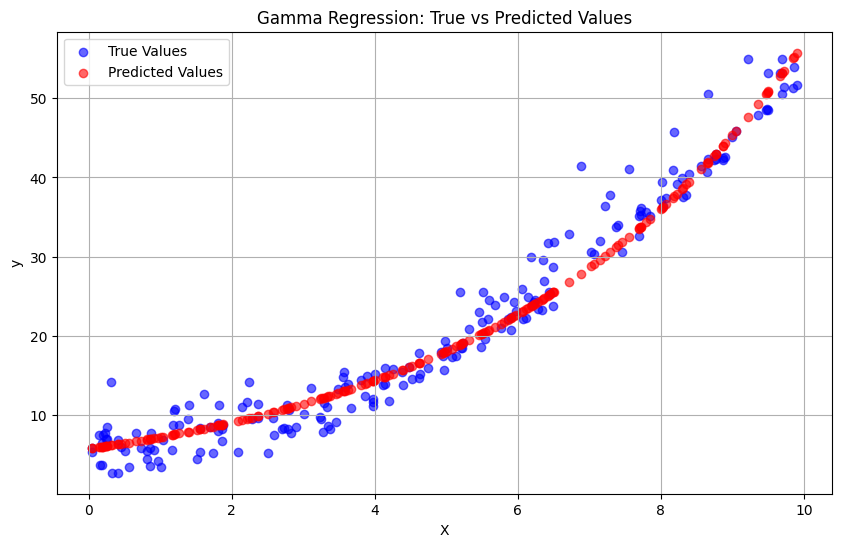

In [3]:
# 使用 TweedieRegressor 建立 Gamma Regression 模型
# label: "TweedieRegressor" and title: "Gamma Regression Model"
from sklearn.metrics import mean_squared_error

# 创建模型实例, power=2 表示目标变量服从 Gamma 分布, link='log' 是对数链接函数的常用选择
gamma_reg = TweedieRegressor(power=2, alpha=0.5, link='log', max_iter=1000)

# 训练模型
gamma_reg.fit(X_train, y_train)

# 使用训练好的模型进行预测
y_pred = gamma_reg.predict(X_test)

# 评价模型效果
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# 绘制预测值与真实值的对比图
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='True Values')
plt.scatter(X_test, y_pred, color='red', alpha=0.6, label='Predicted Values')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Gamma Regression: True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()